In [241]:
import pandas as pd
import xgboost as xgb
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer  # Nécessaire pour activer l'IterativeImputer
from sklearn.impute import IterativeImputer
import missingno as msno
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.cluster import KMeans
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import IsolationForest

In [242]:
def load_data(name):
    df = pd.read_csv(name)
    return df

In [243]:
def data_search_isna(df):
    return df.isna().sum()

In [244]:
def data_remplace_Mode_isna(df):
    # Remplacement par la valeur la plus fréquente (Mode)
    for col in ["State", "BankState", "NewExist", "LowDoc","RevLineCr"]:
        df[col] = df[col].fillna(df[col].mode()[0])

In [245]:
def data_remplace_MIS_STATUS(df):
    for col in ["FranchiseCode", "RevLineCr", "LowDoc"]:
        df["MIS_Status"] = df.groupby(col)["MIS_Status"].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "PIF"))


In [246]:
def data_Correlation_mis_status(df_num):

    # Calculer la matrice de corrélation
    corr_matrix = df_num.corr()

    # Afficher la heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Matrice de corrélation")
    plt.show()


In [247]:
def calcul_Correlation_cat(df, cat_vars):
    df_=df[cat_vars+["MIS_Status"]].copy()
    # Stocker les résultats
    correlations = {}

    for col in cat_vars:
        contingency_table = pd.crosstab(df[col], df["MIS_Status"])
        chi2, p_value, _, _ = chi2_contingency(contingency_table)
        correlations[col] = p_value  # Plus le p-value est petit, plus la relation est forte

    # Trier par ordre croissant de p-value (plus c'est bas, plus c'est corrélé)
    sorted_correlations = sorted(correlations.items(), key=lambda x: x[1])

    # Afficher les résultats
    for col, p_val in sorted_correlations:
        print(f"Variable: {col} - p-value: {p_val}")

In [248]:
def calcul_Correlation_Pearson(df, cat_vars):

    # Encoder MIS_Status en 0 et 1
    df["MIS_Status_Encoded"] = df["MIS_Status"]#.apply(lambda x: 1 if x == "PIF" else 0)

    # Encoder toutes les variables catégorielles
    encoder = LabelEncoder()
    encoded_cat_vars = {}

    for col in cat_vars:
        df[col] = df[col].astype(str)  # Convertir en string
        df[col + "_Encoded"] = encoder.fit_transform(df[col])
        encoded_cat_vars[col] = col + "_Encoded"

    # Calculer la corrélation de Pearson
    correlation_matrix = df[["MIS_Status_Encoded"] + list(encoded_cat_vars.values())].corr()

    # Extraire les corrélations avec MIS_Status
    mis_status_corr = correlation_matrix["MIS_Status_Encoded"].drop("MIS_Status_Encoded")

    # Trier et afficher les résultats
    print(mis_status_corr.abs().sort_values(ascending=False))

In [249]:
df=load_data("preparation_data.csv")

In [250]:
df.head(50)

,Term,FranchiseCode,State,BankState,NAICS_2,NoEmp,NewExist,RetainedJob,CreateJob,UrbanRural,RevLineCr,ApprovalFY,DisbursementGross,GrAppv,LowDoc,MIS_Status
0,84,1,IN,OH,45,4,2.0,0,0,0,0.0,1997,60000.0,60000.0,1.0,1.0
1,60,1,IN,IN,72,2,2.0,0,0,0,0.0,1997,40000.0,40000.0,1.0,1.0
2,180,1,IN,IN,62,7,1.0,0,0,0,0.0,1997,287000.0,287000.0,0.0,1.0
3,60,1,OK,OK,0,2,1.0,0,0,0,0.0,1997,35000.0,35000.0,1.0,1.0
4,240,1,FL,FL,0,14,1.0,7,7,0,0.0,1997,229000.0,229000.0,0.0,1.0
5,120,1,CT,DE,33,19,1.0,0,0,0,0.0,1997,517000.0,517000.0,0.0,1.0
6,45,0,NJ,SD,0,45,2.0,0,0,0,0.0,1980,600000.0,600000.0,0.0,0.0
7,84,1,FL,AL,81,1,2.0,0,0,0,0.0,1997,45000.0,45000.0,1.0,1.0
8,297,1,FL,FL,72,2,2.0,0,0,0,0.0,1997,305000.0,305000.0,0.0,1.0
9,84,1,CT,CT,0,3,2.0,0,0,0,0.0,1997,70000.0,70000.0,1.0,1.0


In [251]:

# Création des nouvelles variables
recession_years = [2008, 2009, 2020]  # Exemples d'années de récession
df['RecessionPeriod'] = df['ApprovalFY'].apply(lambda x: 1 if x in recession_years else 0)
df['Loan_Usage_Ratio'] = df['DisbursementGross'] / df['GrAppv']
df['Employee_Loan_Ratio'] = df['NoEmp'] / df['GrAppv']
df['JobImpact'] = df['CreateJob'] + df['RetainedJob']
#df['Loan_Term_Category'] = pd.cut(df['Term'], bins=[0, 60, 120, np.inf], labels=['Court', 'Moyen', 'Long'])

# Variables sélectionnées
num_vars = ['ApprovalFY', 'Term', 'DisbursementGross','UrbanRural', 'GrAppv', 'NoEmp', 'Loan_Usage_Ratio', 'Employee_Loan_Ratio', 'JobImpact']
cat_vars = ['NewExist', 'FranchiseCode', 'RevLineCr', 'LowDoc', 'RecessionPeriod','State', 'BankState', 'NAICS_2']#, 'Loan_Term_Category']


In [252]:
#num_vars = ['Term', 'NoEmp', 'RetainedJob', 'CreateJob', 'UrbanRural', 'ApprovalFY', 'DisbursementGross', 'GrAppv', 'MIS_Status']
#cat_vars = ['FranchiseCode', 'State', 'BankState', 'NAICS_2', 'NewExist', 'RevLineCr', 'LowDoc']    
#print(df.info())
data_remplace_Mode_isna(df)
#data_Correlation_mis_status(df[num_vars])
data_remplace_MIS_STATUS(df)

In [253]:
for col in cat_vars :
    print(f"Valeurs uniques pour {col} :")
    print(df[col].value_counts())
    print()

Valeurs uniques pour NewExist :
NewExist
1.0    645005
2.0    253125
0.0      1034
Name: count, dtype: int64

Valeurs uniques pour FranchiseCode :
FranchiseCode
1    690329
0    208835
Name: count, dtype: int64

Valeurs uniques pour RevLineCr :
RevLineCr
0.0    697744
1.0    201420
Name: count, dtype: int64

Valeurs uniques pour LowDoc :
LowDoc
0.0    788829
1.0    110335
Name: count, dtype: int64

Valeurs uniques pour RecessionPeriod :
RecessionPeriod
0    840498
1     58666
Name: count, dtype: int64

Valeurs uniques pour State :
State
CA    130633
TX     70458
NY     57693
FL     41212
PA     35170
OH     32622
IL     29669
MA     25272
MN     24373
NJ     24035
WA     23263
GA     22277
WI     21040
MO     20678
CO     20605
MI     20545
UT     18776
AZ     17631
NC     14294
IN     14132
MD     13269
VA     13264
CT     12229
NH     12109
IA     11996
KS     11464
OR     11051
OK      9950
LA      9576
ID      9498
TN      9403
RI      9028
MT      8749
AL      8362
NV      8024
KY

In [254]:
for col in num_vars :
    print(f"Valeurs uniques pour {col} :")
    print(df[col].value_counts())
    print()

Valeurs uniques pour ApprovalFY :
ApprovalFY
2005    77525
2006    76040
2007    71876
2004    68290
2003    58193
1995    45758
2002    44391
1996    40112
2008    39540
1997    37748
2000    37381
1999    37363
2001    37350
1998    36016
1994    31598
1993    23305
1992    20885
2009    19126
2010    16848
1991    15666
1990    14859
1989    13248
2011    12608
2012     5997
2013     2458
1987     2218
1986     2118
1984     2022
1985     1944
1988     1898
1983     1684
1982      719
1981      630
1980      477
1979      352
2014      268
1978      242
1977      137
1976       84
1973       52
1974       42
1975       30
1972       27
1971       20
1970        8
1969        4
1967        2
1968        2
1966        1
1965        1
1962        1
Name: count, dtype: int64

Valeurs uniques pour Term :
Term
84     230162
60      89945
240     85982
120     77654
300     44727
        ...  
438         1
382         1
367         1
374         1
429         1
Name: count, Length: 412, d

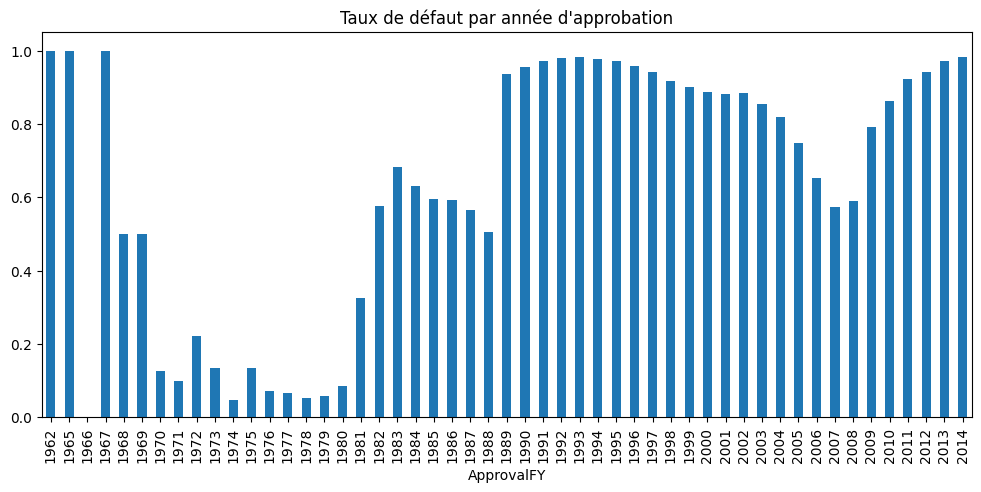

In [255]:
df.groupby("ApprovalFY")["MIS_Status"].mean().plot(kind="bar", figsize=(12, 5))
plt.title("Taux de défaut par année d'approbation")
plt.show()

In [256]:
# Séparation des variables explicatives et de la variable cible
#X = df.drop(columns=["MIS_Status", "State", "BankState"])  # Variables explicatives
#y = df["MIS_Status"]  # Variable cible
# Regrouper les États en clusters avec KMeans
# Convertir State et BankState en valeurs numériques (Label Encoding)

label_encoders = {}
for col in ["State", "BankState"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # On garde l'encodeur si besoin plus tard

print("Clusterssssssssssssssssssssssssssss000000000000")

# Appliquer KMeans pour regrouper State et BankState en clusters
for col in ["State", "BankState"]:
    kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)  # 10 clusters (modifiable)
    df[col + "_Cluster"] = kmeans.fit_predict(df[[col]])

print("Clusterssssssssssssssssssssssssssss")
#df = pd.get_dummies(df, columns=['Loan_Term_Category'], drop_first=False, dtype=int)

# Supprimer les colonnes originales State et BankState
X = df.drop(columns=["MIS_Status","State", "BankState"])#,"Term"
y = df["MIS_Status"]  # Variable cible

# Diviser les données en train et test
X_train_, X_test_, y_train_, y_test_ = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



#scaler = StandardScaler() if normalisation_code == 1 else MaxAbsScaler()
#data_scaled = scaler.fit_transform(data)
#data = pd.DataFrame(data_scaled, columns=data.columns)

# Normalisation des données (centrer et réduire)
#scaler = StandardScaler()  # Ou vous pouvez choisir MinMaxScaler si nécessaire
# Normalisation des données

scaler = StandardScaler()
X_train_scaled_ = pd.DataFrame(scaler.fit_transform(X_train_), columns=X_train_.columns)
X_test_scaled_ = pd.DataFrame(scaler.transform(X_test_), columns=X_test_.columns)

# Détection et suppression des outliers avec IsolationForest
"""iso_forest = IsolationForest(random_state=42)#contamination=0.05, 
outliers = iso_forest.fit_predict(X_train)
X_cleaned = X_train[outliers == 1]
y_cleaned = y_train[outliers == 1]"""

#model = RandomForestClassifier(class_weight='balanced', n_estimators=200, max_depth=15, random_state=42)
#model = AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=42)
#from xgboost import XGBClassifier
#from sklearn.model_selection import GridSearchCV
################################################
execute_=False

if execute_:
    from sklearn.linear_model import SGDClassifier, LogisticRegression
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.ensemble import VotingClassifier,AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
    from sklearn.metrics import classification_report


    model_1 = SGDClassifier(alpha=0.0001, average=False, class_weight=None, random_state=42, loss='log_loss')
    model_2 = DecisionTreeClassifier(random_state=42)
    model_3 = RandomForestClassifier(n_estimators=100, random_state=42)#probleme temps exécution avec KNeighborsClassifier(n_neighbors=2)
    model_4 = LogisticRegression(max_iter=1000, random_state=42)
    model_5 = AdaBoostClassifier(n_estimators=50, random_state=42)
    model_6 = GradientBoostingClassifier(n_estimators=100, random_state=42)
    model_7 = xgb.XGBClassifier(
            n_estimators=200,#200
            max_depth=10,
            learning_rate=0.1,#0.1
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss", 
        )

    """models = model_7
    models.fit(X_train_scaled, y_train)
    y_pred = models.predict(X_test_scaled)
    print(models.__class__.__name__)
    print(classification_report(y_test, y_pred))
    print(models.score(X_test_scaled, y_test))"""

    voting_model  = VotingClassifier(estimators=[
        ('sgd', model_1), 
        ('tree', model_2), 
        ('rf', model_3),
        ('lr', model_4),
        ('ada',model_5),
        ('gb',model_6),
        ('xgb',model_7),
    ], voting='soft')#hard

    for models in (model_1, model_2, model_3, model_4, model_5, model_6,model_7, voting_model ):
        models.fit(X_train_scaled_, y_train_)
        y_pred = models.predict(X_test_scaled_)
        print(models.__class__.__name__)
        print(classification_report(y_test_, y_pred))
        print(models.score(X_test_scaled_, y_test_))
    ####################################################


Clusterssssssssssssssssssssssssssss000000000000
Clusterssssssssssssssssssssssssssss


In [257]:
#pd.set_option('display.max_columns', 30)
#df.dtypes

Summarize dataset:  83%|████████▎ | 24/29 [00:19<00:02,  2.13it/s, Calculate auto correlation]           c:\Users\asus\OneDrive\Bureau\Formations\USSBA_Classification\Brief04_USSBA_classification\.venv\Lib\site-packages\ydata_profiling\model\pandas\discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[2 2 2 ... 0 2 2]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(
c:\Users\asus\OneDrive\Bureau\Formations\USSBA_Classification\Brief04_USSBA_classification\.venv\Lib\site-packages\ydata_profiling\model\pandas\discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[6 3 3 ... 0 2 2]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize

Calcul des poids (accuracy moyen) pour chaque classifieur :
Calcul du accuracy pour XGB...
Performance de XGB : 0.9508
              precision    recall  f1-score   support

         0.0       0.89      0.84      0.86     31512
         1.0       0.97      0.98      0.97    148321

    accuracy                           0.95    179833
   macro avg       0.93      0.91      0.92    179833
weighted avg       0.95      0.95      0.95    179833

Accuracy 0.9532343896837622
AUC 0.9805832767248287
Temps d'exécution pour XGB : 173.80 secondes
Vecteur de poids normalisés (accuracy) : [1.]


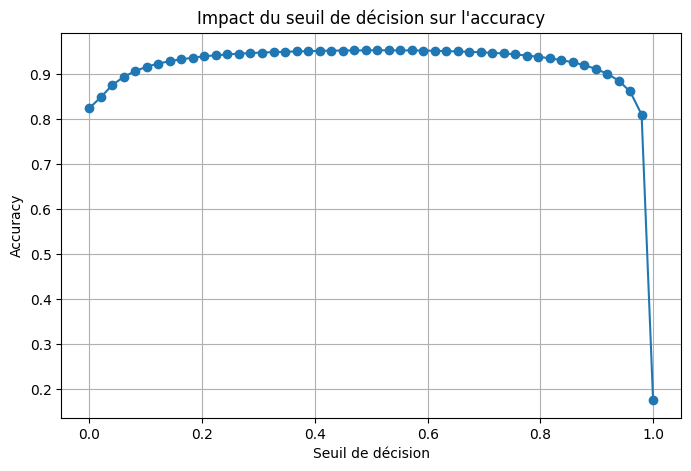


Performances après fusion par pondération:
{'Accuracy': 0.9532733146864035, 'Precision': 0.9671906720803505, 'Recall': 0.9764699536815421, 'F1-Score': 0.9718081626490866, 'AUC': 0.9805832767248287}

Résultats enregistrés dans results_accuracy_XGB_Outliers0_Scaling1_Poly0_PCA0_2025-02-11_15-44-39.json


In [258]:
from datetime import datetime
import time
import numpy as np
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.ensemble import IsolationForest
import xgboost as xgb
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
import json
from itertools import product
from xgboost import cv, DMatrix
import optuna

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Définition de la métrique choisie
chosen_metric = "accuracy"  # Options : "recall", "precision", "accuracy", "f1", "roc_auc"

# Détection et suppression des outliers avec IsolationForest
use_outlier_detection = False
if use_outlier_detection:
    iso = IsolationForest(contamination=0.05, random_state=42)
    outliers = iso.fit_predict(X_train)
    mask = outliers != -1  # Conserver uniquement les valeurs normales
    X_train, y_train = X_train[mask], y_train[mask]

use_scaling = True
if use_scaling:
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
       
# Transformation polynomiale
use_polynomial_features = False
if use_polynomial_features:
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)
else:
    X_train_poly, X_test_poly = X_train_scaled, X_test_scaled

# Réduction de dimension avec PCA
use_pca = False
if use_pca:
    pca = PCA(n_components=0.95)  # Garde 95% de la variance
    X_train_pca = pca.fit_transform(X_train_poly)
    X_test_pca = pca.transform(X_test_poly)
else:
    X_train_pca, X_test_pca = X_train_poly, X_test_poly

"""# Définition des classifieurs
base_classifier = {
    #"LogReg": LogisticRegression(max_iter=1000, random_state=42),
    #"RF": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGB": xgb.XGBClassifier(
            n_estimators=200,#200
            max_depth=10,
            learning_rate=0.1,#0.1
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss", 
        ),
    #"GB": GradientBoostingClassifier(n_estimators=100, random_state=42),
    #"SGD": SGDClassifier(alpha=0.0001, average=False, class_weight=None, random_state=42, loss='log_loss'),
    #"DTC": DecisionTreeClassifier(random_state=42),
    #"Ada": AdaBoostClassifier(n_estimators=50, random_state=42),
}

# Définition des classifieurs
other_classifiers = {
    "LogReg": LogisticRegression(max_iter=1000, random_state=42),
    "RF": RandomForestClassifier(n_estimators=100, random_state=42),
    "GB": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "SGD": SGDClassifier(alpha=0.0001, average=False, class_weight=None, random_state=42, loss='log_loss'),
    "DTC": DecisionTreeClassifier(random_state=42),
    "Ada": AdaBoostClassifier(n_estimators=50, random_state=42),
} 

X_train_transformed = X_train_pca
X_test_transformed = X_test_pca

# Tester chaque combinaison de classifieurs avec XGBoost
test_results = {}
for name, clf in other_classifiers.items():
    classifiers = {"XGB": base_classifier["XGB"], name: clf}
    weights = {}
    performances = {}
    print("All classfiers",name)
    for clf_name, model in classifiers.items():
        score = cross_val_score(model, X_train_transformed, y_train, cv=3, scoring=chosen_metric).mean()
        weights[clf_name] = score
        model.fit(X_train_transformed, y_train)
        y_pred = model.predict(X_test_transformed)
        y_proba = model.predict_proba(X_test_transformed)[:, 1]
        print("Accuracy:", accuracy_score(y_test, y_pred))
        print("f1:", f1_score(y_test, y_pred, zero_division=0))
        performances[clf_name] = {
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1-Score": f1_score(y_test, y_pred, zero_division=0),
            "AUC": roc_auc_score(y_test, y_proba)
        }
    
    # Fusion des modèles
    probs = np.array([model.predict_proba(X_test_transformed)[:, 1] for model in classifiers.values()])
    weight_vector = np.array(list(weights.values()))
    weight_vector = weight_vector / weight_vector.sum() if weight_vector.sum() != 0 else np.ones_like(weight_vector) / len(weight_vector)
    final_prob = np.average(probs, axis=0, weights=weight_vector)

    thresholds = np.linspace(0, 1, 50)
    accuracies = [accuracy_score(y_test, (final_prob >= t).astype(int)) for t in thresholds]
    best_threshold = thresholds[np.argmax(accuracies)]
    final_pred = (final_prob >= best_threshold).astype(int)

    fusion_performance = {
        "chosen_metric": chosen_metric,
        "Accuracy": accuracy_score(y_test, final_pred),
        "Precision": precision_score(y_test, final_pred, zero_division=0),
        "Recall": recall_score(y_test, final_pred, zero_division=0),
        "F1-Score": f1_score(y_test, final_pred, zero_division=0),
        "AUC": roc_auc_score(y_test, final_prob)
    }
    print("Accuracy:", accuracy_score(y_test, final_pred))
    print("f1:", f1_score(y_test, final_pred, zero_division=0))
    print("f1:", roc_auc_score(y_test, final_prob))

    test_results[name] = {
        "weights": weights,
        "best_threshold": best_threshold,
        "individual_performances": performances,
        "fusion_performance": fusion_performance
    }

# Sauvegarde des résultats
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
file_name = f"results_{chosen_metric}_XGB_comparisons_{timestamp}.json"
with open(file_name, "w") as f:
    json.dump(test_results, f, indent=4)

print(f"\nRésultats enregistrés dans {file_name}")"""

X_train_fusion = X_train_pca
X_test_fusion = X_test_pca

from ydata_profiling import ProfileReport
# Générer un rapport de profilage
profile = ProfileReport(df, title="Rapport de Profilage", explorative=True)

# Sauvegarder le rapport au format HTML
profile.to_file("rapport_profilage.html")

"""def objective(trial):
    # Définir l'espace de recherche des hyperparamètres
    params = {
        "objective": "binary:logistic",
        "eval_metric": "error",
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "subsample": trial.suggest_uniform("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_uniform("colsample_bytree", 0.5, 1.0),
        "random_state": 42,
    }

    print("modele a entrainer")
    # Entraîner le modèle
    model = xgb.XGBClassifier(**params)
    model.fit(X_train_fusion, y_train)

    print("modele a evaluer")
    # Prédire et évaluer
    y_pred = model.predict_proba(X_test_fusion)[:, 1]
    return roc_auc_score(y_test, y_pred)

print("modele a optimiser")
# Lancer l'optimisation
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

# Meilleurs paramètres trouvés
best_params = study.best_params
print("Meilleurs hyperparamètres :", best_params)

# Entraîner le modèle final avec les meilleurs hyperparamètres
final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train)"""

#AUC
"""[I 2025-02-11 11:19:54,422] Trial 49 finished with value: 0.9803137743112862 
and parameters: {'max_depth': 12, 'learning_rate': 0.018502699801100222, 'n_estimators': 479, 
'subsample': 0.9205422734355616, 'colsample_bytree': 0.9479418943069773}. 

Best is trial 44 with value: 0.9806014299067516.
Meilleurs hyperparamètres : {'max_depth': 12, 'learning_rate': 0.033130740518160916, 'n_estimators': 493, 
'subsample': 0.8827609371578583, 'colsample_bytree': 0.9943657039536032}

#Error:
[I 2025-02-11 14:28:09,739] Trial 49 finished with value: 0.980156340399245 and parameters: 
{'max_depth': 11, 'learning_rate': 0.04875475433123523, 'n_estimators': 209, 'subsample': 0.8103427219016471, 
'colsample_bytree': 0.8481948850648799}. 

Best is trial 31 with value: 0.9805832767248287.
Meilleurs hyperparamètres : 
						{'max_depth': 11, 
						'learning_rate': 0.037218185907558744, 
						'n_estimators': 457, 
						'subsample': 0.7276565595780007, 
						'colsample_bytree': 0.8843040106742441
						}
"""
"""dtrain = DMatrix(X_train_fusion, label=y_train)
dtest = DMatrix(X_test_fusion, label=y_test)

# Définir les paramètres de base
params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "max_depth": 10,
    "learning_rate": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
}

print("Cross-Validation XgBoost")
# Effectuer une cross-validation pour trouver le meilleur `n_estimators`
cv_results = xgb.cv(
    params,
    dtrain,
    num_boost_round=300,  # Nombre max d'arbres
    nfold=3,  # Cross-validation à 5 folds
    early_stopping_rounds=5,  # Arrêter si le score ne s'améliore pas en 10 itérations
    metrics="auc",
    as_pandas=True
)

# Nombre optimal d'arbres (meilleure itération)
best_n_estimators = cv_results.shape[0]
print(f"Meilleur nombre d'estimateurs : {best_n_estimators}")

# Entraîner le modèle final avec le meilleur n_estimators
params["n_estimators"] = best_n_estimators
final_model = xgb.XGBClassifier(**params)
final_model.fit(X_train_fusion, y_train)

# Évaluer sur les données de test
y_pred = final_model.predict(X_test_fusion)
print(f"Score final : {roc_auc_score(y_test, y_pred)}")

"""
# Calcul des poids des classifieurs

classifiers = {
    #"LogReg": LogisticRegression(max_iter=1000, random_state=42),
    #"RF": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGB": xgb.XGBClassifier(
            n_estimators=457,#200
            max_depth=11,
            learning_rate=0.037218185907558744,#0.1
            subsample=0.7276565595780007,
            colsample_bytree=0.8843040106742441,
            random_state=42,
            eval_metric="logloss", 
        ),
    #"GB": GradientBoostingClassifier(n_estimators=100, random_state=42),
    #"SGD": SGDClassifier(alpha=0.0001, average=False, class_weight=None, random_state=42, loss='log_loss'),
    #"DTC": DecisionTreeClassifier(random_state=42),
    #"Ada": AdaBoostClassifier(n_estimators=50, random_state=42),
}

print(f"Calcul des poids ({chosen_metric} moyen) pour chaque classifieur :")
weights = {}
performances = {}

for name, clf in classifiers.items():
    start_time = time.time()
    print(f"Calcul du {chosen_metric} pour {name}...")

    try:
        score = cross_val_score(clf, X_train_fusion, y_train, cv=2, scoring=chosen_metric).mean()
    except ValueError:
        score = 0  # Gestion des erreurs si les classes ne sont pas bien distribuées
    weights[name] = score

    clf.fit(X_train_fusion, y_train)
    y_pred = clf.predict(X_test_fusion)
    y_proba = clf.predict_proba(X_test_fusion)[:, 1]

    print(f"Performance de {name} : {score:.4f}")
    print(classification_report(y_test, y_pred))
    print("Accuracy", accuracy_score(y_test, y_pred))
    print("AUC", roc_auc_score(y_test, y_proba))

    performances[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_test, y_proba)
    }

    print(f"Temps d'exécution pour {name} : {time.time() - start_time:.2f} secondes")

# Normalisation des poids
probs = np.array([clf.predict_proba(X_test_fusion)[:, 1] for clf in classifiers.values()])
weight_vector = np.array(list(weights.values()))
weight_vector = weight_vector / weight_vector.sum() if weight_vector.sum() != 0 else np.ones_like(weight_vector) / len(weight_vector)

print(f"Vecteur de poids normalisés ({chosen_metric}) :", weight_vector)

# Moyenne pondérée des probabilités
final_prob = np.average(probs, axis=0, weights=weight_vector)

# Variation du seuil
thresholds = np.linspace(0, 1, 50)
accuracies = [accuracy_score(y_test, (final_prob >= t).astype(int)) for t in thresholds]

# Graphique
plt.figure(figsize=(8, 5))
plt.plot(thresholds, accuracies, marker='o', linestyle='-')
plt.xlabel("Seuil de décision")
plt.ylabel("Accuracy")
plt.title("Impact du seuil de décision sur l'accuracy")
plt.grid()
plt.show()

# Seuil optimal
best_threshold = thresholds[np.argmax(accuracies)]
final_pred = (final_prob >= best_threshold).astype(int)

# Évaluation finale
fusion_performance = {
    "Accuracy": accuracy_score(y_test, final_pred),
    "Precision": precision_score(y_test, final_pred, zero_division=0),
    "Recall": recall_score(y_test, final_pred, zero_division=0),
    "F1-Score": f1_score(y_test, final_pred, zero_division=0),
    "AUC": roc_auc_score(y_test, final_prob)
}

print("\nPerformances après fusion par pondération:")
print(fusion_performance)

# Enregistrement des résultats
results = {
    "chosen_metric": chosen_metric,
    "weights": weights,
    "weight_vector": weight_vector.tolist(),  # Conversion en liste pour JSON
    "best_threshold": best_threshold,
    "individual_performances": performances,
    "fusion_performance": fusion_performance,
}

# Création du nom de fichier avec les classifieurs, la métrique et les transformations
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
classifier_names = "_".join(classifiers.keys())
transformations = f"Outliers{int(use_outlier_detection)}_Scaling{int(use_scaling)}_Poly{int(use_polynomial_features)}_PCA{int(use_pca)}"
file_name = f"results_{chosen_metric}_{classifier_names}_{transformations}_{timestamp}.json"

# Enregistrement des résultats
with open(file_name, "w") as f:
    json.dump(results, f, indent=4)

print(f"\nRésultats enregistrés dans {file_name}")

In [259]:
if execute_:
    import time
    import numpy as np
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    import xgboost as xgb
    from sklearn.model_selection import cross_val_score
    from sklearn.metrics import classification_report

    # Définition de la métrique choisie
    chosen_metric = "roc_auc"  # Options : "recall", "precision", "accuracy", "f1", "roc_auc"

    # 1. Définir plusieurs classifieurs
    clf1 = LogisticRegression(max_iter=1000, random_state=42)
    clf2 = RandomForestClassifier(n_estimators=100, random_state=42)
    clf3 = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)

    # Liste des classifieurs et noms associés
    classifiers = [clf1, clf2, clf3]
    classifier_names = ['LogReg', 'RF', 'XGB']

    # 2. Calcul des poids en fonction de la métrique choisie
    print(f"Calcul des poids ({chosen_metric} moyen) pour chaque classifieur :")
    weights = {}
    for name, clf in zip(classifier_names, classifiers):
        start_time = time.time()  # Début du chronométrage
        
        print(f"Calcul du {chosen_metric} pour {name}...")
        score = cross_val_score(clf, X_train_scaled, y_train, cv=5, scoring=chosen_metric).mean()
        weights[name] = score
        
        elapsed_time = time.time() - start_time  # Temps écoulé
        print(f"Temps d'exécution pour {name} : {elapsed_time:.2f} secondes")

    print(f"Poids ({chosen_metric} moyens) :", weights)

    # 3. Entraînement des classifieurs
    print("\nEntraînement des classifieurs :")
    for clf in classifiers:
        start_time = time.time()
        
        print(f"Entraînement de {clf.__class__.__name__}...")
        clf.fit(X_train_scaled, y_train)
        
        elapsed_time = time.time() - start_time
        print(f"Temps d'entraînement pour {clf.__class__.__name__} : {elapsed_time:.2f} secondes")

    # 4. Récupération des probabilités prédites
    probs = []
    for clf in classifiers:
        start_time = time.time()
        
        probs.append(clf.predict_proba(X_test_scaled)[:, 1])
        
        elapsed_time = time.time() - start_time
        print(f"Temps de prédiction pour {clf.__class__.__name__} : {elapsed_time:.2f} secondes")

    # Convertir la liste en tableau NumPy : (n_classifieurs, n_samples)
    probs = np.array(probs)

    # 5. Création du vecteur de poids basé sur la métrique choisie
    weight_vector = np.array([weights[name] for name in classifier_names])

    # Éviter la division par zéro si les poids sont tous nuls
    if weight_vector.sum() == 0:
        weight_vector = np.ones_like(weight_vector) / len(weight_vector)
    else:
        weight_vector = weight_vector / weight_vector.sum()  # Normalisation

    print(f"Vecteur de poids normalisés ({chosen_metric}) :", weight_vector)

    # 6. Calcul de la probabilité finale (moyenne pondérée)
    start_time = time.time()

    final_prob = np.average(probs, axis=0, weights=weight_vector)

    elapsed_time = time.time() - start_time
    print(f"Temps de calcul des probabilités pondérées : {elapsed_time:.2f} secondes")

    # 7. Appliquer un seuil pour obtenir les prédictions finales (seuil = 0.5)
    start_time = time.time()

    threshold = 0.5
    final_pred = (final_prob >= threshold).astype(int)

    elapsed_time = time.time() - start_time
    print(f"Temps de binarisation des prédictions finales : {elapsed_time:.2f} secondes")

    # 8. Affichage du rapport de classification
    print("\nRapport de classification :")
    print(classification_report(y_test, final_pred))


In [260]:
"""param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False,
)

model = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='roc_auc',  # ou 'accuracy' selon votre objectif
    cv=5,
    verbose=1,
    n_jobs=-1  # utiliser tous les cœurs disponibles
)"""
##################################################################
"""model = xgb.XGBClassifier(
        n_estimators=200,#200
        max_depth=10,
        learning_rate=0.1,#0.1
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss", 
    )"""
################################################################
"""xgb_model = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,  # Important pour éviter les warnings et erreurs
    eval_metric="logloss"
)
rf_model = RandomForestClassifier(random_state=42)
lr_model = LogisticRegression(random_state=42)

# Créer le VotingClassifier
ensemble_model = VotingClassifier(estimators=[
    ('xgb', xgb_model),
    ('rf', rf_model),
    ('lr', lr_model)
], voting='soft')"""

#smote = SMOTE(random_state=42)
#X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train) --> 94% avec 20 mn entrainement

'xgb_model = xgb.XGBClassifier(\n    random_state=42,\n    use_label_encoder=False,  # Important pour éviter les warnings et erreurs\n    eval_metric="logloss"\n)\nrf_model = RandomForestClassifier(random_state=42)\nlr_model = LogisticRegression(random_state=42)\n\n# Créer le VotingClassifier\nensemble_model = VotingClassifier(estimators=[\n    (\'xgb\', xgb_model),\n    (\'rf\', rf_model),\n    (\'lr\', lr_model)\n], voting=\'soft\')'

In [261]:
ensemble_model = model

ensemble_model.fit(X_train, y_train)

# Apprendre le modèle
#model = LogisticRegression(max_iter=6000)
#model.fit(X_train_scaled, y_train)  # Utiliser X_train_scaled pour l'entraînement

# Prédiction
y_pred = ensemble_model.predict(X_test)  # Utiliser X_test_scaled pour la prédiction

# Évaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


# Il faut voir les valeurs Nan et leurs significations et impacts sur le modèle
# Il faut voir l'impact des valeurs outliers ISOLATION FOREST

# Vérifier l'importance des features
importances = ensemble_model.feature_importances_
features = X_train.columns

# Affichage des features les plus importantes
plt.figure(figsize=(10, 5))
sns.barplot(x=importances, y=features)
plt.title("Importance des Features")
plt.show()

NameError: name 'model' is not defined